In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv("../Data/Raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Assign Column Types

In [73]:
numerical_features = df.select_dtypes(include=["int64", 'float64']).columns.tolist()
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [74]:
categorical_features = df.select_dtypes(include=['str']).columns.tolist()
categorical_features

['ocean_proximity']

In [75]:
# Droping Target Variable from Numerical Features
# Target_variable -> median_house_value

numerical_features.remove('median_house_value')

### Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


In [76]:
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [77]:
df['longitude'].describe()

count    20640.000000
mean      -119.569704
std          2.003532
min       -124.350000
25%       -121.800000
50%       -118.490000
75%       -118.010000
max       -114.310000
Name: longitude, dtype: float64

<Axes: xlabel='longitude', ylabel='Density'>

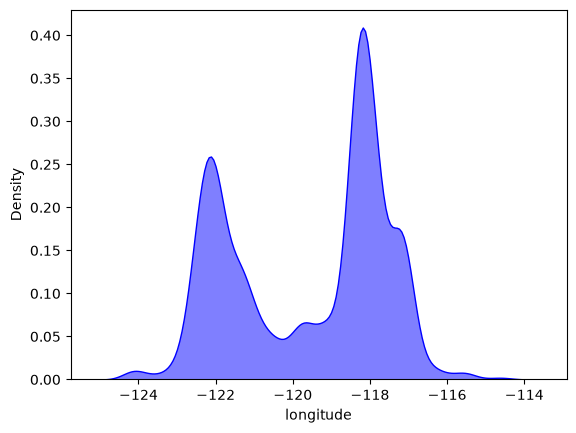

In [78]:
sns.kdeplot(df["longitude"], fill=True, color="blue", alpha=0.5)  # There is Bimodal Distribution in Data

<Axes: ylabel='Frequency'>

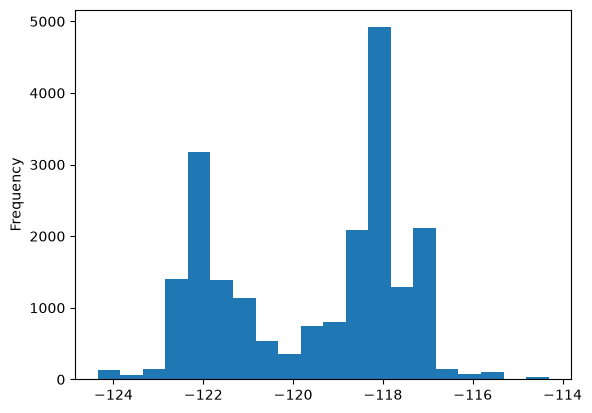

In [79]:
df['longitude'].plot(kind="hist", bins=20)

In [80]:
df['longitude'].skew()

np.float64(-0.2978012079524363)

<Axes: >

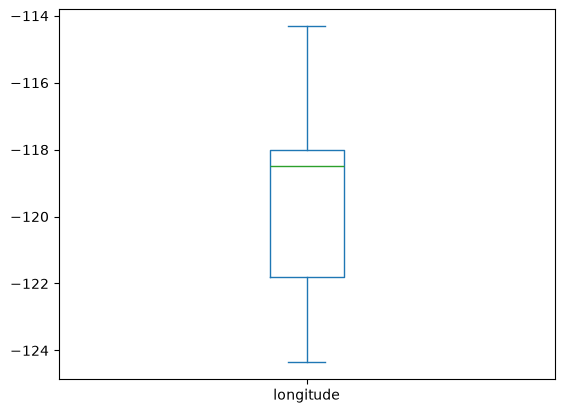

In [81]:
# Detecting Outliers 
df['longitude'].plot(kind='box')
# There are no Such Outliers in Data

In [82]:
# CONCLUSION
# 1. There is bimodal Distribution in Data
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data


In [83]:
df['latitude'].describe()

count    20640.000000
mean        35.631861
std          2.135952
min         32.540000
25%         33.930000
50%         34.260000
75%         37.710000
max         41.950000
Name: latitude, dtype: float64

<Axes: xlabel='latitude', ylabel='Density'>

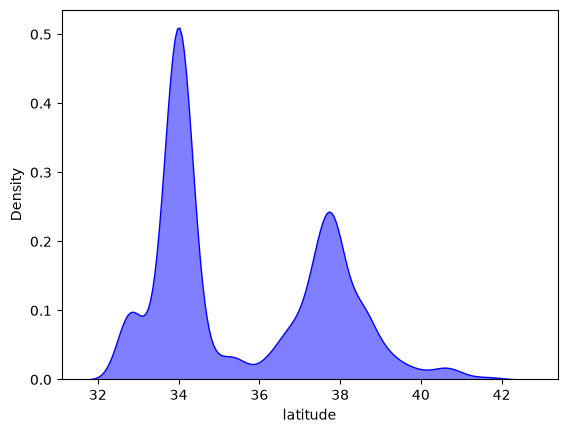

In [84]:
sns.kdeplot(df["latitude"], fill=True, color="blue", alpha=0.5) #There is a bimodal Distribution 

<Axes: ylabel='Frequency'>

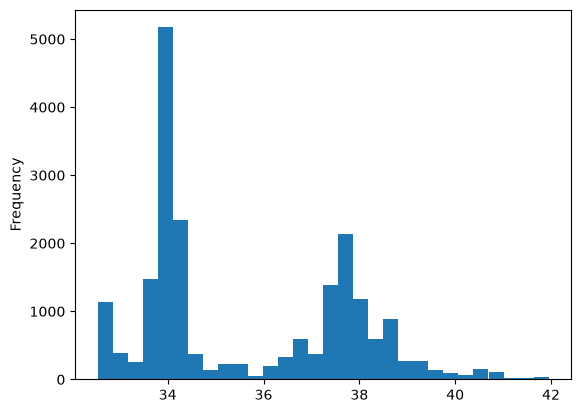

In [85]:
df['latitude'].plot(kind='hist',bins=30)

<Axes: >

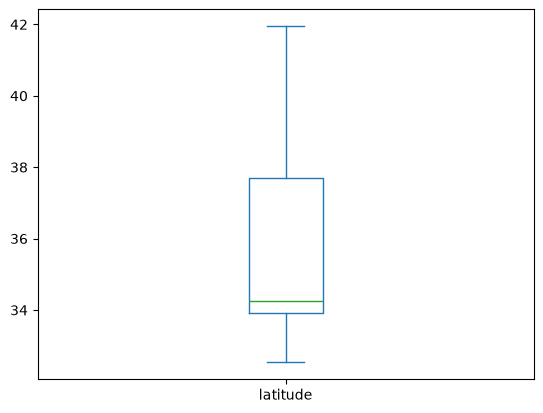

In [86]:
# Detecting Outliers 
df['latitude'].plot(kind='box')
#There are no such Outliers in the Data


In [87]:
df['latitude'].skew()

np.float64(0.4659530037099799)

In [88]:
# CONCLUSION
# 1. There is bimodal Distribution in Data
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data 
# 4. Data distribution is approximately symmetric with a slight positive (right) skew.

In [89]:
df['housing_median_age'].describe()

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

<Axes: xlabel='housing_median_age', ylabel='Density'>

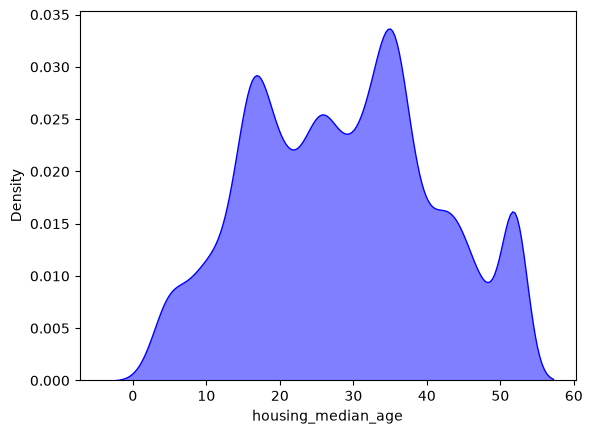

In [90]:
sns.kdeplot(df['housing_median_age'], fill=True, color='Blue',alpha=0.5)

<Axes: ylabel='Frequency'>

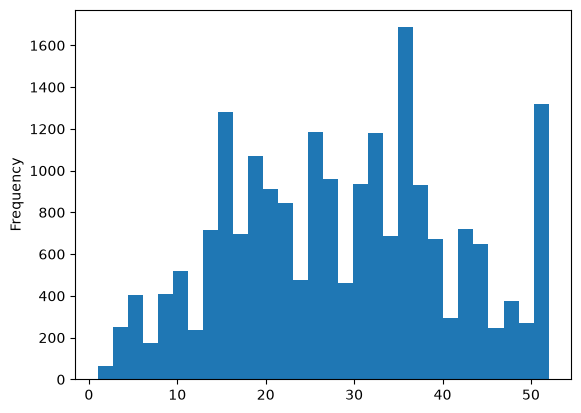

In [91]:
df['housing_median_age'].plot(kind='hist', bins=30)

In [92]:
df['housing_median_age'].skew()

np.float64(0.06033063759913685)

<Axes: >

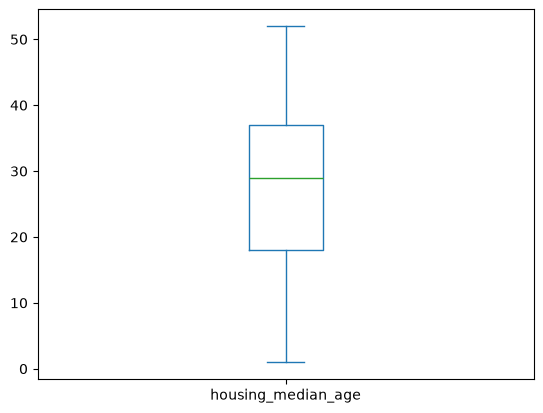

In [93]:
df['housing_median_age'].plot(kind='box')

In [94]:
#In conclusion, 
# 1. this is a multimodal distribution spanning roughly 0 to 55 years, 
#    featuring a prominent peak at 35 years and a sharp artificial cap near 52 years.
# 2. There are no such Outliers in the Data
# 3. No Missing Values in Data


In [95]:
df['total_rooms'].describe()

count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

<Axes: xlabel='total_rooms', ylabel='Density'>

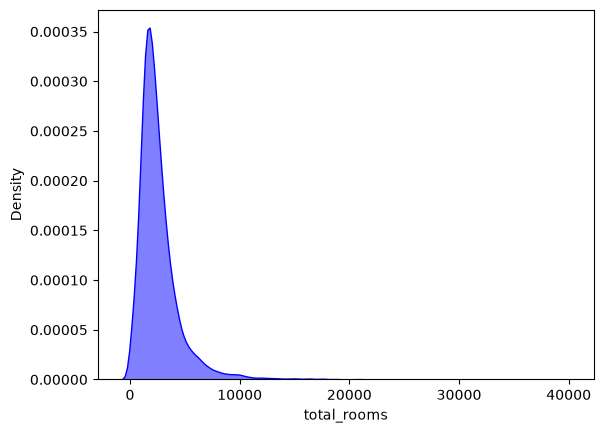

In [96]:
sns.kdeplot(df['total_rooms'], fill=True, color="blue", alpha=0.5) 

<Axes: ylabel='Frequency'>

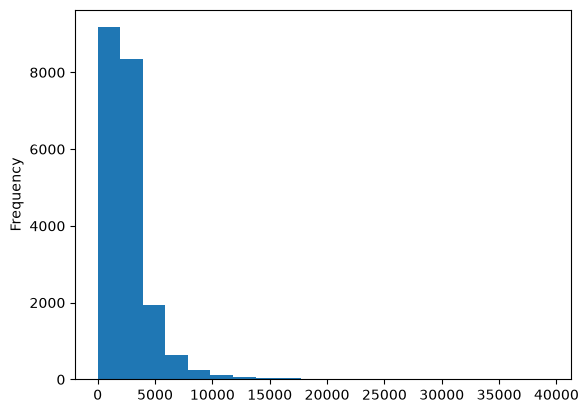

In [97]:
df['total_rooms'].plot(kind='hist', bins=20)

In [98]:
df['total_rooms'].skew() #Total_rooms Data is highly Right Skewwed

np.float64(4.147343450632158)

<Axes: >

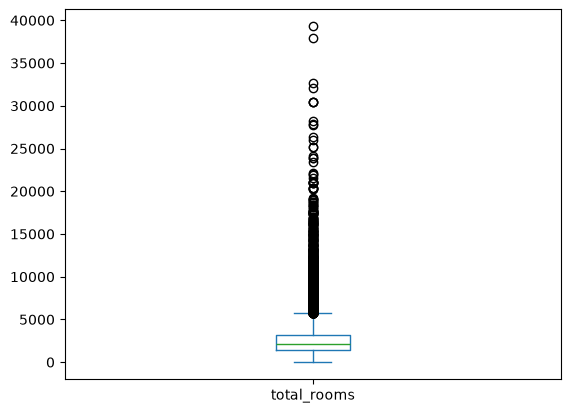

In [99]:
df['total_rooms'].plot(kind='box')

In [100]:
import pandas as pd

# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['total_rooms'].quantile(0.25)
Q3 = df['total_rooms'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['total_rooms'] < lower_bound) | (df['total_rooms'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in total_rooms: {total_outliers}")


Lower Bound: -1102.625
Upper Bound: 5698.375
Total outliers in total_rooms: 1287


In [101]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1287 ouliers in total_rooms Column
# 3. There are no missiong values there

In [102]:
df['total_bedrooms'].describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [103]:
df['total_bedrooms'].isnull().sum()
#There are total 207 missing values

np.int64(207)

<Axes: xlabel='total_bedrooms', ylabel='Density'>

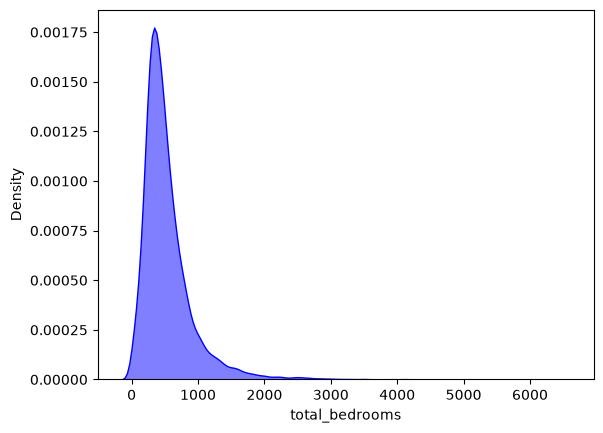

In [104]:
sns.kdeplot(df['total_bedrooms'], fill=True, color='Blue', alpha=0.5)

In [105]:
df['total_bedrooms'].skew() #Highly Right Skewed

np.float64(3.459546331523342)

<Axes: >

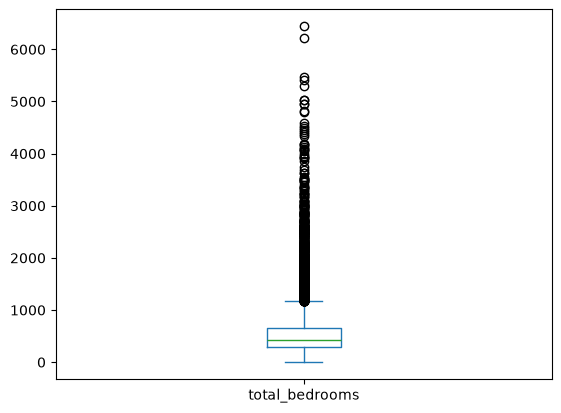

In [106]:
df['total_bedrooms'].plot(kind="box")

In [107]:
# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['total_bedrooms'].quantile(0.25)
Q3 = df['total_bedrooms'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['total_bedrooms'] < lower_bound) | (df['total_bedrooms'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in total_bedrooms: {total_outliers}")

Lower Bound: -230.5
Upper Bound: 1173.5
Total outliers in total_bedrooms: 1271


In [108]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1271 ouliers in total_bedrooms Column
# 3. There are a total 207 missiong values 

In [109]:
df['population'].describe()

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: population, dtype: float64

<Axes: xlabel='population', ylabel='Density'>

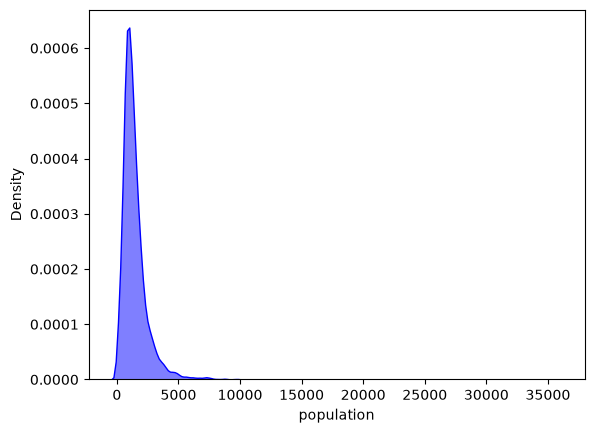

In [110]:
sns.kdeplot(df['population'], fill=True, alpha=0.5, color="Blue")

In [111]:
df['population'].skew() #Highly Right skewed

np.float64(4.935858226727124)

<Axes: >

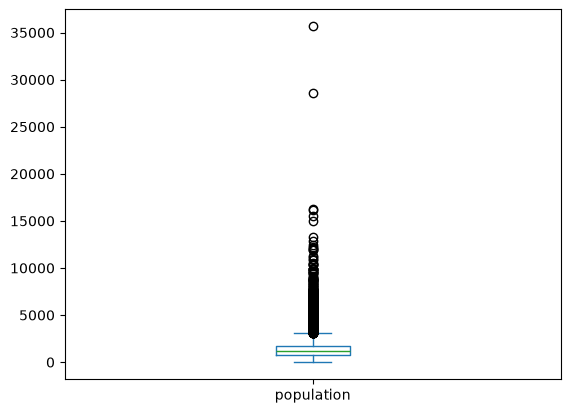

In [112]:
df['population'].plot(kind='box')

In [113]:
# 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
Q1 = df['population'].quantile(0.25)
Q3 = df['population'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['population'] < lower_bound) | (df['population'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in population: {total_outliers}")

Lower Bound: -620.0
Upper Bound: 3132.0
Total outliers in population: 1196


In [114]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1196 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [115]:
df['households'].describe()

count    20640.000000
mean       499.539680
std        382.329753
min          1.000000
25%        280.000000
50%        409.000000
75%        605.000000
max       6082.000000
Name: households, dtype: float64

<Axes: xlabel='households', ylabel='Density'>

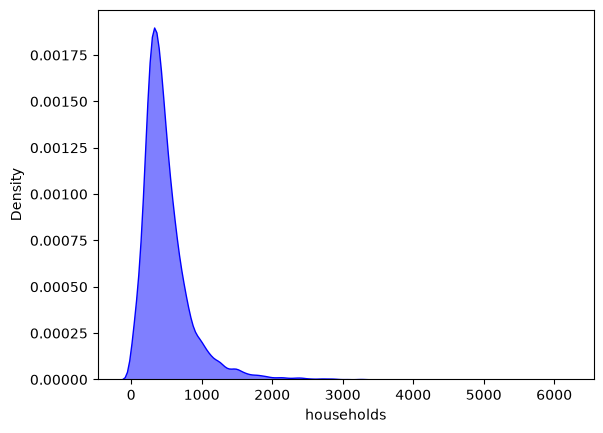

In [116]:
sns.kdeplot(df['households'], fill=True, alpha=0.5, color="Blue")

In [117]:
df['households'].skew() #Highly Right Skewed

np.float64(3.4104377116671474)

<Axes: >

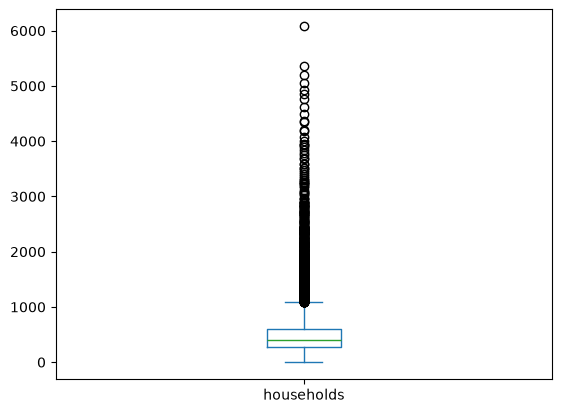

In [118]:
df['households'].plot(kind='box')

In [119]:
Q1 = df['households'].quantile(0.25)
Q3 = df['households'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['households'] < lower_bound) | (df['households'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in households: {total_outliers}")

Lower Bound: -207.5
Upper Bound: 1092.5
Total outliers in households: 1220


In [120]:
#Conclusion 
# 1. Data is highly right skewed
# 2. There are total 1220 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [121]:
df['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

<Axes: xlabel='median_income', ylabel='Density'>

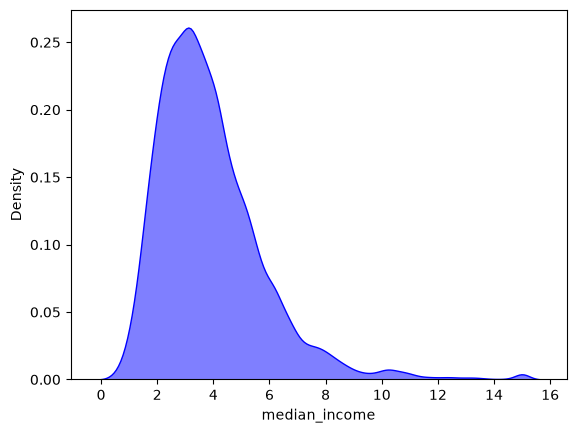

In [122]:
sns.kdeplot(df['median_income'], fill=True, alpha=0.5, color="Blue")

In [123]:
df['median_income'].skew() #right skewed

np.float64(1.6466567021344465)

<Axes: >

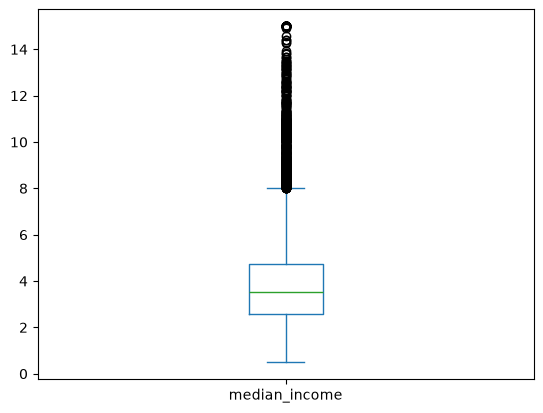

In [124]:
df['median_income'].plot(kind='box')

In [125]:
Q1 = df['median_income'].quantile(0.25)
Q3 = df['median_income'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define boundaries (1.5 times the IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter and count the outliers
outliers = df[(df['median_income'] < lower_bound) | (df['median_income'] > upper_bound)]
total_outliers = len(outliers)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total outliers in median_income: {total_outliers}")

Lower Bound: -0.7063750000000004
Upper Bound: 8.013024999999999
Total outliers in median_income: 681


In [126]:
#Conclusion 
# 1. Data is right skewed
# 2. There are total 681 ouliers in total_bedrooms Column
# 3. There are no missiong values 

In [127]:
df['ocean_proximity'].describe()

count         20640
unique            5
top       <1H OCEAN
freq           9136
Name: ocean_proximity, dtype: object

<Axes: xlabel='ocean_proximity', ylabel='Count'>

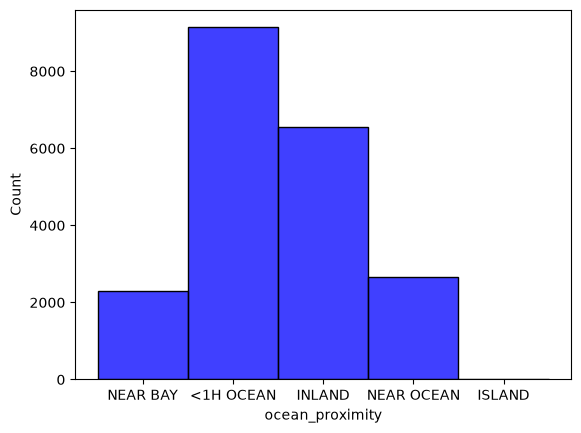

In [128]:
sns.histplot(df['ocean_proximity'], fill=True, color="blue")

In [129]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: >

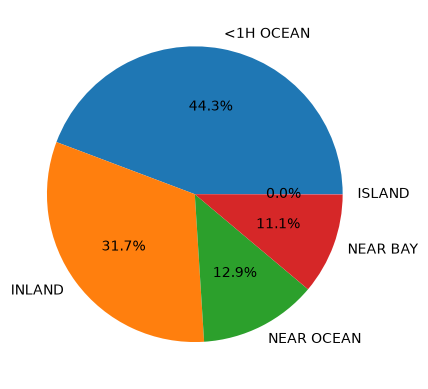

In [130]:
df['ocean_proximity'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions

In [131]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


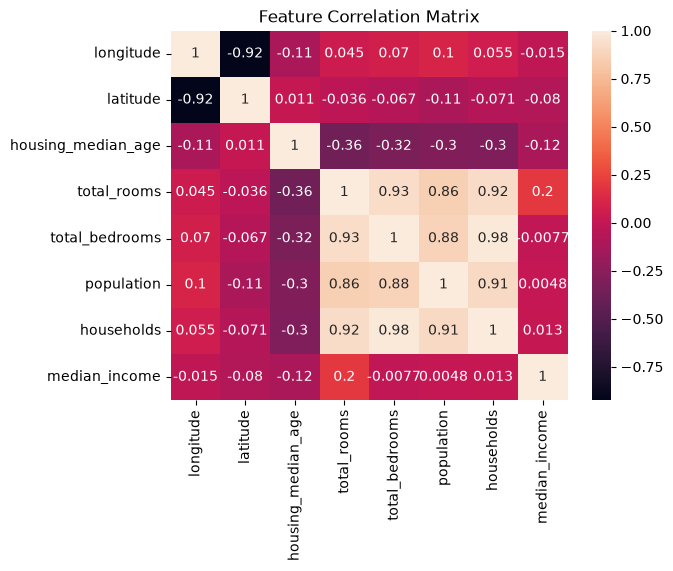